# Abacaxi Capital Management & Equities (ACME) - Rotulação de Notícias Financeiras

## Objetivo
O Objetivo deste projeto é utilizar um modelo preditivo tradicional para rotular textos de acordo com o conteúdo do corpo e comparar seu desempenho com o de Large Language Models modernos (LLMs).

In [13]:
# Importa bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# importa dados de data/Dataset.tsv
url = "https://raw.githubusercontent.com/mstagomori/desafio-ciencia-dados-inoa/main/data/Dataset.tsv"

df = pd.read_csv(url, sep="\t")

df.head()

,id,headline,text,asset_class
0,1,Milho fecha em alta com clima adverso em regia...,Milho fecha em alta com clima adverso em regia...,commodities
1,2,"Certificado de deposito bancario oferece 9,6% ...","Certificado de deposito bancario oferece 9,6% ...",fixed_income
2,3,Aprovacao de fundo negociado de criptoativos i...,Aprovacao de fundo negociado de criptoativos i...,crypto
3,4,AeroBras surpreendeu o mercado com margem EBIT...,AeroBras surpreendeu o mercado com margem EBIT...,equities
4,5,Investidores institucionais ampliam exposicao ...,Investidores institucionais ampliam exposicao ...,crypto


## Analise Exploratória

In [15]:
# Valores nulos
df.isnull().sum()

id             0
headline       0
text           0
asset_class    0
dtype: int64

### Valores Duplicados (Headline e Text)

In [31]:
# Retorna headlines duplicados
df[df.duplicated(subset='headline', keep=False)]

,id,headline,text,asset_class,chars_headline,chars_text,words_headline,words_text
0,1,Milho fecha em alta com clima adverso em regia...,Milho fecha em alta com clima adverso em regia...,commodities,68,259,11,38
2,3,Aprovacao de fundo negociado de criptoativos i...,Aprovacao de fundo negociado de criptoativos i...,crypto,65,199,9,29
3,4,AeroBras surpreendeu o mercado com margem EBIT...,AeroBras surpreendeu o mercado com margem EBIT...,equities,68,255,10,40
4,5,Investidores institucionais ampliam exposicao ...,Investidores institucionais ampliam exposicao ...,crypto,60,256,6,32
5,6,Milho fecha em alta com clima adverso em regia...,Milho fecha em alta com clima adverso em regia...,commodities,68,294,11,42
...,...,...,...,...,...,...,...,...
5991,5992,Tesouro nacional realiza leilao de titulos pre...,Tesouro nacional realiza leilao de titulos pre...,fixed_income,78,260,11,40
5992,5993,TelecomOnda reportou queda de 1% no lucro do u...,TelecomOnda reportou queda de 1% no lucro do u...,equities,61,300,10,43
5994,5995,Empresa capta R$ 36 bilhoes em emissao de debe...,Empresa capta R$ 36 bilhoes em emissao de debe...,fixed_income,65,245,10,37
5997,5998,ImobiliariaVicta recebeu recomendacao de compr...,IMOBILIARIAVICTA RECEBEU RECOMENDACAO DE COMPR...,crypto,83,234,10,32


In [32]:
# Retorna text duplicados
df[df.duplicated(subset='text', keep=False)]

,id,headline,text,asset_class,chars_headline,chars_text,words_headline,words_text


In [33]:
# Registros com Text duplicados
print("Número de registros duplicados:", df[df.duplicated(subset=['text'], keep=False)].shape[0])
    
# Remove duplicados mantendo o primeiro registro
df = df.drop_duplicates(subset=['text'], keep='first')

Número de registros duplicados: 0


Como registros duplicados não contribuem com informação relevante para o modelo, os duplicados foram removidos, mantendo o primeiro

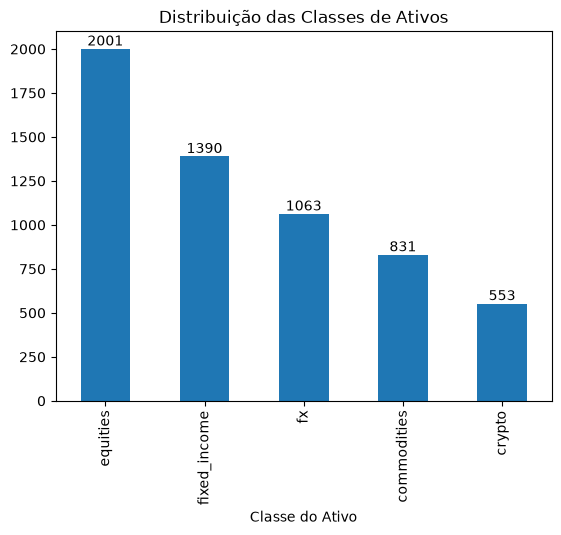

In [34]:
# PLota Distribuição de classes
df['asset_class'].value_counts().plot(kind='bar')
plt.xlabel('Classe do Ativo')
plt.title('Distribuição das Classes de Ativos')
for index, value in enumerate(df['asset_class'].value_counts()):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

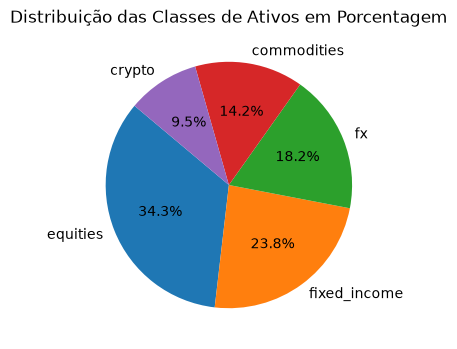

In [35]:
# Distribuição de classes em porcentagem
classes_porcentagem = df['asset_class'].value_counts(normalize=True) * 100

# Plota a distribuição de classes em pie plot
plt.figure(figsize=(4, 4))
plt.pie(classes_porcentagem, labels=classes_porcentagem.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribuição das Classes de Ativos em Porcentagem')
plt.show()

Pode-se perceber um desbalanceamento de classes, com equities e fixed_income tomando mais de 50% dos dados e crypto apenas 9.5%

In [36]:
# Cria novas colunas com o número de caracteres e palavras em 'headline' e 'text'
df['chars_headline'] = df['headline'].fillna('').str.len()
df['chars_text'] = df['text'].fillna('').str.len()

df['words_headline'] = df['headline'].fillna('').str.split().str.len()
df['words_text'] = df['text'].fillna('').str.split().str.len()

### Distribuição de Caracteres e Palavras

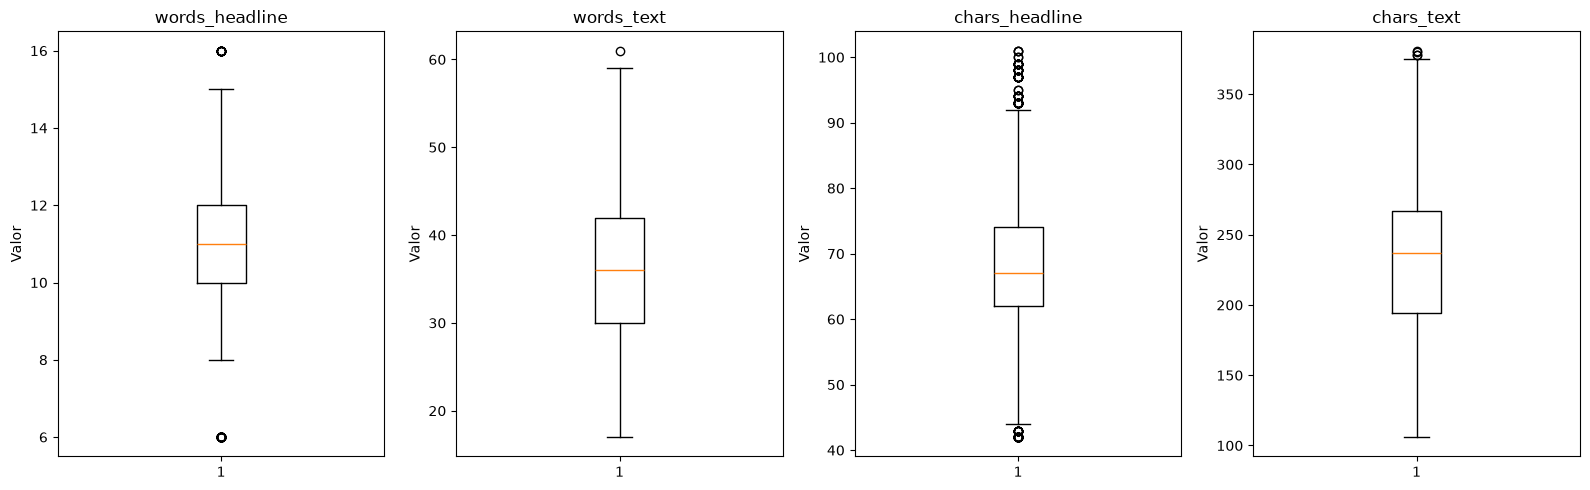

In [24]:
colunas = [
    'words_headline',
    'words_text',
    'chars_headline',
    'chars_text'
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, coluna in zip(axes, colunas):
    ax.boxplot(df[coluna].dropna())
    ax.set_title(coluna)
    ax.set_ylabel('Valor')

plt.tight_layout()
plt.show()

### Jargões
Utilizando uma função para identificar jargões financeiros compostos de mais de uma palvra e uní-los com _ para que o modelo os compreenda como apenas uma palavra. \
A lista de jargões foi gerada através de GenAI, utilizando o dataset como input para buscar por jargões do mercado financeiro, e posteriormente analisada.

In [38]:
financial_jargons = [
    "ações ordinárias",
    "ações preferenciais",
    "curva de juros",
    "receita líquida",
    "lucro líquido",
    "margem EBITDA",
    "renda fixa",
    "indexado à inflação",
    "fundo de renda fixa",
    "dólar comercial",
    "fluxo cambial",
    "Banco Central",
    "política monetária",
    "dívida pública",
    "fluxo estrangeiro",
    "gestores de fundos",
    "mesas de operação",
    "taxa básica",
    "juros futuros",
    "mercado de ações",
    "mercado cambial"
]

In [39]:
def replace_multiword_jargons(text, jargons):
    for jargon in jargons:
        if " " in jargon:
            replacement = jargon.replace(" ", "_")

            text = text.replace(
                jargon,
                replacement
            )

    return text

In [40]:
df["text_processed"] = df["text"].apply(
    lambda x: replace_multiword_jargons(
        x,
        financial_jargons
    )
)